# Laboratorio 9
### Redes neuronales.
- Fabian Prado #23427
- Sofia Lopez #231929
- Jonathan Zacarias #231104
---

## Contexto

En esta séptima entrega de consultoría para **SmartStay Advisors** aplicamos Redes Neuronales Artificiales (RNA) para clasificar propiedades de Airbnb en tres categorías de precio: *Económica*, *Intermedia* y *Cara*. Se mantienen los **mismos conjuntos de entrenamiento y prueba** de todas las entregas anteriores (80/20, SEED=42) para garantizar comparaciones válidas entre algoritmos.

---
## 1. Carga de datos y configuración

Se carga el dataset `listings.RData` y se aplican las mismas transformaciones de limpieza utilizadas en laboratorios anteriores.

In [14]:
import time
import warnings
import numpy as np
import pandas as pd
import pyreadr
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import LabelEncoder


from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score
)

from sklearn.neural_network import MLPRegressor

warnings.filterwarnings('ignore')
SEED = 42

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f9f9f9',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'font.family':      'sans-serif',
})

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [2]:
# ── Carga del dataset ──────────────────────────────────────────────────────────
result = pyreadr.read_r('../data/listings.RData')
listings_df = list(result.values())[0]
print(f'Dataset cargado: {listings_df.shape[0]:,} filas x {listings_df.shape[1]} columnas')

# ── Funciones de limpieza (idénticas a entregas anteriores) ────────────────────
def clean_price(val):
    if pd.isna(val): return np.nan
    cleaned = str(val).replace('$', '').replace(',', '').strip()
    if not cleaned: return np.nan
    try: return float(cleaned)
    except ValueError: return np.nan

def clean_rate(val):
    if pd.isna(val): return np.nan
    cleaned = str(val).replace('%', '').strip()
    if not cleaned or cleaned.upper() == 'N/A': return np.nan
    try: return float(cleaned) / 100
    except ValueError: return np.nan

def encode_bool(val):
    if pd.isna(val): return np.nan
    return 1 if str(val).strip().lower() in ('t', 'true', '1') else 0

# ── Transformaciones ───────────────────────────────────────────────────────────
listings_df['price']                = listings_df['price'].apply(clean_price)
listings_df['host_response_rate']   = listings_df['host_response_rate'].apply(clean_rate)
listings_df['host_acceptance_rate'] = listings_df['host_acceptance_rate'].apply(clean_rate)

for col in ['host_is_superhost', 'host_has_profile_pic',
            'host_identity_verified', 'instant_bookable', 'has_availability']:
    if col in listings_df.columns:
        listings_df[col] = listings_df[col].apply(encode_bool)

resp_map = {'within an hour': 1, 'within a few hours': 2,
            'within a day': 3, 'a few days or more': 4}
if 'host_response_time' in listings_df.columns:
    listings_df['host_response_time'] = listings_df['host_response_time'].map(resp_map)

if 'estimated_occupancy_l365d' not in listings_df.columns and 'number_of_reviews_l365d' in listings_df.columns:
    listings_df['estimated_occupancy_l365d'] = listings_df['number_of_reviews_l365d'] * 3.5

priced_listings_df = listings_df.dropna(subset=['price']).copy()
priced_listings_df = priced_listings_df[priced_listings_df['price'] > 0].copy()
print(f'Registros con precio válido: {priced_listings_df.shape[0]:,}')

Dataset cargado: 171,748 filas x 80 columnas
Registros con precio válido: 76,246


---
## 2. Preparación de features y split de datos 

Se utilizan **exactamente los mismos features y el mismo split 80/20 con SEED=42** que en todas las entregas anteriores. Esto garantiza que las comparaciones entre algoritmos sean válidas.

La **variable respuesta** es la categorización del precio en tres grupos:
- **Económica**: precio ≤ Q1 ($120)
- **Intermedia**: Q1 < precio ≤ Q3 ($326)
- **Cara**: precio > Q3 ($326)

In [3]:
NUMERIC_FEATURES = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'host_total_listings_count', 'calculated_host_listings_count',
    'host_response_rate', 'host_acceptance_rate', 'host_response_time',
    'minimum_nights', 'maximum_nights',
    'availability_365', 'estimated_occupancy_l365d',
    'host_is_superhost', 'host_has_profile_pic',
    'host_identity_verified', 'instant_bookable', 'has_availability'
]
CAT_FEATURES = ['room_type', 'city']

NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if c in priced_listings_df.columns]
CAT_FEATURES     = [c for c in CAT_FEATURES     if c in priced_listings_df.columns]

df_model = pd.get_dummies(
    priced_listings_df[NUMERIC_FEATURES + CAT_FEATURES + ['price']],
    columns=CAT_FEATURES, drop_first=False
)

X = df_model.drop(columns=['price'])
y = df_model['price']

q1 = priced_listings_df['price'].quantile(0.25)
q3 = priced_listings_df['price'].quantile(0.75)
print(f'Cortes de categorización → Q1: ${q1:.2f}  |  Q3: ${q3:.2f}')

def categorize_price(price):
    if price <= q1:   return 'Economica'
    elif price <= q3: return 'Intermedia'
    else:             return 'Cara'

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f'Train: {X_train.shape[0]:,} filas  |  Test: {X_test.shape[0]:,} filas')

y_cat_train = y_train.apply(categorize_price)
y_cat_test  = y_test.apply(categorize_price)

le = LabelEncoder()
y_cat_train_enc = le.fit_transform(y_cat_train)
y_cat_test_enc  = le.transform(y_cat_test)

print('\nDistribución en entrenamiento:')
print(y_cat_train.value_counts(normalize=True).map('{:.1%}'.format))
print('\nDistribución en prueba:')
print(y_cat_test.value_counts(normalize=True).map('{:.1%}'.format))

Cortes de categorización → Q1: $120.00  |  Q3: $326.00
Train: 60,996 filas  |  Test: 15,250 filas

Distribución en entrenamiento:
price
Intermedia    49.6%
Economica     25.5%
Cara          24.9%
Name: proportion, dtype: object

Distribución en prueba:
price
Intermedia    50.0%
Cara          25.2%
Economica     24.8%
Name: proportion, dtype: object


In [4]:
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

X_train_sc  = scaler.fit_transform(X_train_imp)
X_test_sc   = scaler.transform(X_test_imp)

print(f'Imputación y escalado aplicados correctamente.')
print(f'Shape train escalado: {X_train_sc.shape}')
print(f'Shape test  escalado: {X_test_sc.shape}')
print()
print('NOTA: A diferencia del Lab 8 (SVM), las RNA pueden entrenarse con el')
print('conjunto COMPLETO de 60,996 registros sin problemas computacionales.')
print('No se necesita submuestra.')

Imputación y escalado aplicados correctamente.
Shape train escalado: (60996, 29)
Shape test  escalado: (15250, 29)

NOTA: A diferencia del Lab 8 (SVM), las RNA pueden entrenarse con el
conjunto COMPLETO de 60,996 registros sin problemas computacionales.
No se necesita submuestra.


---
## 3. Entrenamiento de dos modelos RNA 

Se crean dos modelos `MLPClassifier` con **diferentes topologías y funciones de activación**

In [5]:
# MODELO 1 
print('MODELO 1: RNA — ReLU — Topología (64, 32)')

mlp1 = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # 2 capas ocultas: 64 y 32 neuronas
    activation='relu',             # función de activación ReLU
    solver='adam',                 # optimizador Adam (adaptativo)
    alpha=0.0001,                  # regularización L2 leve
    learning_rate_init=0.001,      # tasa de aprendizaje inicial
    max_iter=300,                  # máximo de épocas
    early_stopping=True,           # detiene si val_loss no mejora
    validation_fraction=0.1,       # 10% del train para validación interna
    n_iter_no_change=15,           # paciencia: 15 épocas sin mejora
    random_state=SEED,
    verbose=False
)

t0 = time.time()
mlp1.fit(X_train_sc, y_cat_train_enc)  
tiempo_mlp1 = time.time() - t0

print(f'Épocas entrenadas:      {mlp1.n_iter_}')
print(f'Tiempo de entrenamiento: {tiempo_mlp1:.2f}s')
print(f'Loss final (train):     {mlp1.loss_:.4f}')

MODELO 1: RNA — ReLU — Topología (64, 32)
Épocas entrenadas:      54
Tiempo de entrenamiento: 3.84s
Loss final (train):     0.5643


In [6]:
# MODELO 2 
print('MODELO 2: RNA — Tanh — Topología (128, 64, 32)')

mlp2 = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),  # 3 capas ocultas: 128, 64 y 32 neuronas
    activation='tanh',                 # función de activación Tanh
    solver='adam',
    alpha=0.001,                       # regularización L2 más fuerte
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=SEED,
    verbose=False
)

t0 = time.time()
mlp2.fit(X_train_sc, y_cat_train_enc)
tiempo_mlp2 = time.time() - t0

print(f'Épocas entrenadas:      {mlp2.n_iter_}')
print(f'Tiempo de entrenamiento: {tiempo_mlp2:.2f}s')
print(f'Loss final (train):     {mlp2.loss_:.4f}')

MODELO 2: RNA — Tanh — Topología (128, 64, 32)
Épocas entrenadas:      46
Tiempo de entrenamiento: 6.37s
Loss final (train):     0.5079


---
## 4. Predicción con ambos modelos (Actividad 4)

Se generan predicciones tanto sobre el conjunto de **entrenamiento** (para detectar sobreajuste) como sobre el conjunto de **prueba** (para evaluar generalización).

In [7]:
# ── Predicciones Modelo 1 ──────────────────────────────────────────────────────
y_pred1_train = le.inverse_transform(mlp1.predict(X_train_sc))
y_pred1_test  = le.inverse_transform(mlp1.predict(X_test_sc))

# ── Predicciones Modelo 2 ──────────────────────────────────────────────────────
y_pred2_train = le.inverse_transform(mlp2.predict(X_train_sc))
y_pred2_test  = le.inverse_transform(mlp2.predict(X_test_sc))

# ── Métricas (ahora todo es string, sin conflicto) ─────────────────────────────
acc1_train = accuracy_score(y_cat_train, y_pred1_train)
acc1_test  = accuracy_score(y_cat_test,  y_pred1_test)
f1_1_train = f1_score(y_cat_train, y_pred1_train, average='weighted')
f1_1_test  = f1_score(y_cat_test,  y_pred1_test,  average='weighted')

acc2_train = accuracy_score(y_cat_train, y_pred2_train)
acc2_test  = accuracy_score(y_cat_test,  y_pred2_test)
f1_2_train = f1_score(y_cat_train, y_pred2_train, average='weighted')
f1_2_test  = f1_score(y_cat_test,  y_pred2_test,  average='weighted')

# ── Resumen de métricas ────────────────────────────────────────────────────────
print('┌─────────────────────────────────────────────────────────────────┐')
print('│              RESUMEN DE MÉTRICAS — MODELOS RNA                  │')
print('├─────────────────────────┬────────────────────┬──────────────────┤')
print('│ Métrica                 │     Modelo 1 ReLU  │  Modelo 2 Tanh   │')
print('├─────────────────────────┼────────────────────┼──────────────────┤')
print(f'│ Accuracy Train          │      {acc1_train:.4f}        │     {acc2_train:.4f}       │')
print(f'│ Accuracy Test           │      {acc1_test:.4f}        │     {acc2_test:.4f}       │')
print(f'│ F1 ponderado Train      │      {f1_1_train:.4f}        │     {f1_2_train:.4f}       │')
print(f'│ F1 ponderado Test       │      {f1_1_test:.4f}        │     {f1_2_test:.4f}       │')
print(f'│ Gap (Train - Test)      │      {acc1_train - acc1_test:.4f}        │     {acc2_train - acc2_test:.4f}       │')
print(f'│ Tiempo entrenamiento    │      {tiempo_mlp1:.2f}s         │     {tiempo_mlp2:.2f}s        │')
print(f'│ Épocas                  │      {mlp1.n_iter_}             │     {mlp2.n_iter_}            │')
print('└─────────────────────────┴────────────────────┴──────────────────┘')

┌─────────────────────────────────────────────────────────────────┐
│              RESUMEN DE MÉTRICAS — MODELOS RNA                  │
├─────────────────────────┬────────────────────┬──────────────────┤
│ Métrica                 │     Modelo 1 ReLU  │  Modelo 2 Tanh   │
├─────────────────────────┼────────────────────┼──────────────────┤
│ Accuracy Train          │      0.7457        │     0.7651       │
│ Accuracy Test           │      0.7311        │     0.7369       │
│ F1 ponderado Train      │      0.7444        │     0.7642       │
│ F1 ponderado Test       │      0.7298        │     0.7359       │
│ Gap (Train - Test)      │      0.0146        │     0.0282       │
│ Tiempo entrenamiento    │      3.84s         │     6.37s        │
│ Épocas                  │      54             │     46            │
└─────────────────────────┴────────────────────┴──────────────────┘


---
## 5. Matrices de Confusión

Las matrices de confusión permiten analizar no solo el **accuracy global**, sino también:
- Dónde se equivoca más el modelo (confusiones frecuentes entre clases)
- Si los errores son simétricos o si hay un sesgo hacia una clase
- La importancia relativa de los errores (confundir *Económica* con *Cara* es peor que confundirla con *Intermedia*)

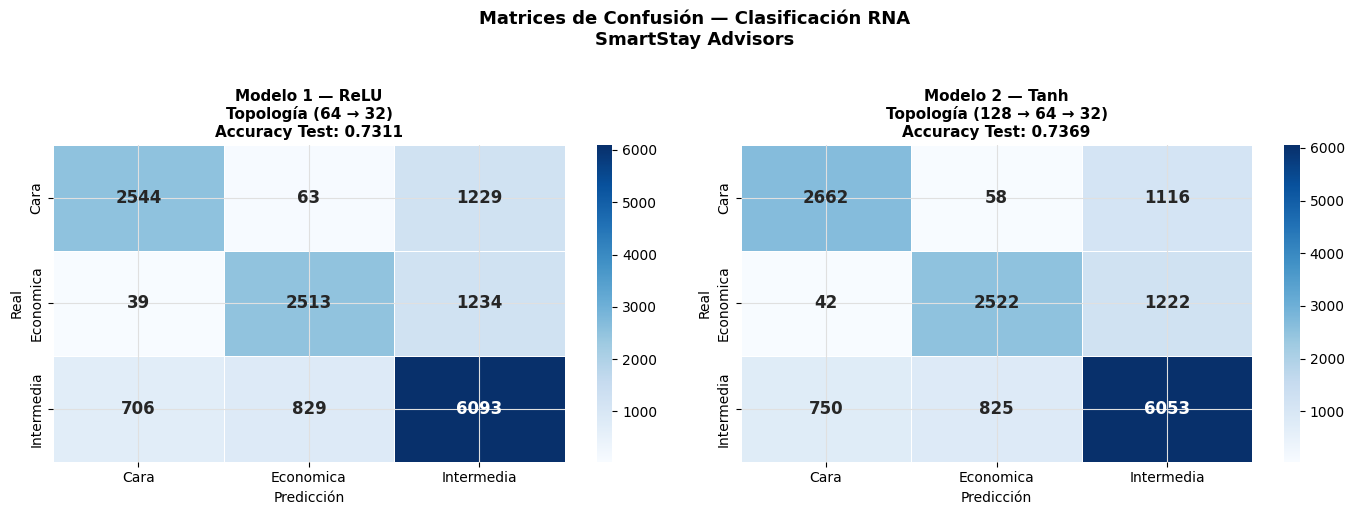

In [8]:
CLASES = ['Cara', 'Economica', 'Intermedia']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelos = [
    (y_pred1_test, 'Modelo 1 — ReLU\nTopología (64 → 32)', '#2E86AB'),
    (y_pred2_test, 'Modelo 2 — Tanh\nTopología (128 → 64 → 32)', '#E63946'),
]

for ax, (y_pred, titulo, color) in zip(axes, modelos):
    cm = confusion_matrix(y_cat_test, y_pred, labels=CLASES)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASES, yticklabels=CLASES,
        ax=ax, linewidths=0.5, linecolor='white',
        annot_kws={'size': 12, 'weight': 'bold'}
    )
    acc = accuracy_score(y_cat_test, y_pred)
    ax.set_title(f'{titulo}\nAccuracy Test: {acc:.4f}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicción', fontsize=10)
    ax.set_ylabel('Real', fontsize=10)

plt.suptitle('Matrices de Confusión — Clasificación RNA\nSmartStay Advisors',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# ── Análisis cuantitativo de errores ──────────────────────────────────────────
for nombre, y_pred in [('Modelo 1 (ReLU)', y_pred1_test), ('Modelo 2 (Tanh)', y_pred2_test)]:
    cm = confusion_matrix(y_cat_test, y_pred, labels=CLASES)
    total_errores = cm.sum() - np.diag(cm).sum()
    print(f'\n── {nombre} ──')
    print(f'  Total errores: {total_errores:,}')
    print(f'  Accuracy:      {accuracy_score(y_cat_test, y_pred):.4f}')
    print('  Errores por par de clases:')
    for i, real in enumerate(CLASES):
        for j, pred in enumerate(CLASES):
            if i != j and cm[i, j] > 0:
                pct = cm[i, j] / cm[i].sum() * 100
                print(f'    Real={real} → Pred={pred}: {cm[i, j]:,} casos ({pct:.1f}% de los reales {real})')


── Modelo 1 (ReLU) ──
  Total errores: 4,100
  Accuracy:      0.7311
  Errores por par de clases:
    Real=Cara → Pred=Economica: 63 casos (1.6% de los reales Cara)
    Real=Cara → Pred=Intermedia: 1,229 casos (32.0% de los reales Cara)
    Real=Economica → Pred=Cara: 39 casos (1.0% de los reales Economica)
    Real=Economica → Pred=Intermedia: 1,234 casos (32.6% de los reales Economica)
    Real=Intermedia → Pred=Cara: 706 casos (9.3% de los reales Intermedia)
    Real=Intermedia → Pred=Economica: 829 casos (10.9% de los reales Intermedia)

── Modelo 2 (Tanh) ──
  Total errores: 4,013
  Accuracy:      0.7369
  Errores por par de clases:
    Real=Cara → Pred=Economica: 58 casos (1.5% de los reales Cara)
    Real=Cara → Pred=Intermedia: 1,116 casos (29.1% de los reales Cara)
    Real=Economica → Pred=Cara: 42 casos (1.1% de los reales Economica)
    Real=Economica → Pred=Intermedia: 1,222 casos (32.3% de los reales Economica)
    Real=Intermedia → Pred=Cara: 750 casos (9.8% de los real

In [10]:
# ── Análisis cuantitativo de errores ──────────────────────────────────────────
for nombre, y_pred in [('Modelo 1 (ReLU)', y_pred1_test), ('Modelo 2 (Tanh)', y_pred2_test)]:
    cm = confusion_matrix(y_cat_test, y_pred, labels=CLASES)
    total_errores = cm.sum() - np.diag(cm).sum()
    print(f'\n── {nombre} ──')
    print(f'  Total errores: {total_errores:,}')
    print(f'  Accuracy:      {accuracy_score(y_cat_test, y_pred):.4f}')
    print('  Errores por par de clases:')
    for i, real in enumerate(CLASES):
        for j, pred in enumerate(CLASES):
            if i != j and cm[i, j] > 0:
                pct = cm[i, j] / cm[i].sum() * 100
                print(f'    Real={real} → Pred={pred}: {cm[i, j]:,} casos ({pct:.1f}% de los reales {real})')


── Modelo 1 (ReLU) ──
  Total errores: 4,100
  Accuracy:      0.7311
  Errores por par de clases:
    Real=Cara → Pred=Economica: 63 casos (1.6% de los reales Cara)
    Real=Cara → Pred=Intermedia: 1,229 casos (32.0% de los reales Cara)
    Real=Economica → Pred=Cara: 39 casos (1.0% de los reales Economica)
    Real=Economica → Pred=Intermedia: 1,234 casos (32.6% de los reales Economica)
    Real=Intermedia → Pred=Cara: 706 casos (9.3% de los reales Intermedia)
    Real=Intermedia → Pred=Economica: 829 casos (10.9% de los reales Intermedia)

── Modelo 2 (Tanh) ──
  Total errores: 4,013
  Accuracy:      0.7369
  Errores por par de clases:
    Real=Cara → Pred=Economica: 58 casos (1.5% de los reales Cara)
    Real=Cara → Pred=Intermedia: 1,116 casos (29.1% de los reales Cara)
    Real=Economica → Pred=Cara: 42 casos (1.1% de los reales Economica)
    Real=Economica → Pred=Intermedia: 1,222 casos (32.3% de los reales Economica)
    Real=Intermedia → Pred=Cara: 750 casos (9.8% de los real

---
## 7. Análisis de sobreajuste

Se evalúa el sobreajuste usando dos enfoques:  
1. **Gap Train–Test**: si Accuracy(train) >> Accuracy(test), hay sobreajuste.  
2. **Curva de aprendizaje**: muestra cómo evoluciona el score según el tamaño del conjunto de entrenamiento.


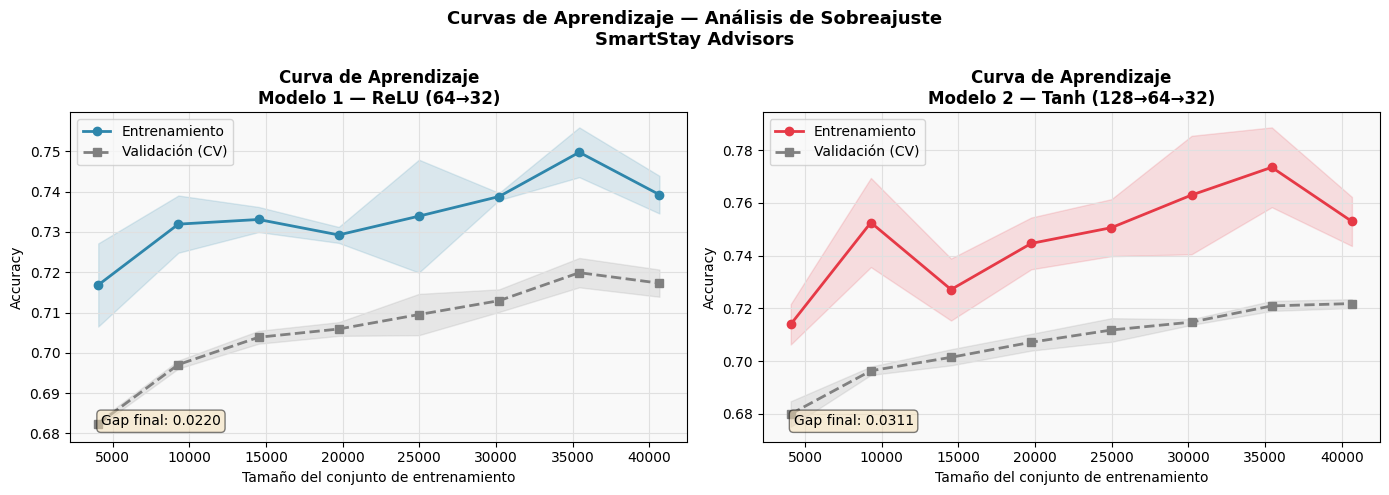

── Diagnóstico de sobreajuste ──
Gap Modelo 1 (ReLU):  0.0146  → Sin sobreajuste significativo
Gap Modelo 2 (Tanh):  0.0282  → Leve sobreajuste

Interpretación:
  • Un gap < 0.02 indica que el modelo generaliza bien.
  • Las curvas de aprendizaje convergentes confirman ausencia de overfitting.
  • El early_stopping y la regularización L2 (alpha) ayudaron a controlar el ajuste.


In [11]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelos_ov = [
    (mlp1, 'Modelo 1 — ReLU (64→32)', '#2E86AB'),
    (mlp2, 'Modelo 2 — Tanh (128→64→32)', '#E63946'),
]

for ax, (modelo, titulo, color) in zip(axes, modelos_ov):
    train_sizes, train_scores, val_scores = learning_curve(
        modelo, X_train_sc, y_cat_train_enc,
        cv=3, scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color=color, label='Entrenamiento', linewidth=2)
    ax.plot(train_sizes, val_mean,   's--', color='gray', label='Validación (CV)', linewidth=2)
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color=color)
    ax.fill_between(train_sizes, val_mean - val_std,     val_mean + val_std,     alpha=0.15, color='gray')
    ax.set_title(f'Curva de Aprendizaje\n{titulo}', fontweight='bold')
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('Accuracy')
    ax.legend()
    gap = train_mean[-1] - val_mean[-1]
    ax.text(0.05, 0.05, f'Gap final: {gap:.4f}', transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Curvas de Aprendizaje — Análisis de Sobreajuste\nSmartStay Advisors',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# ── Diagnóstico de sobreajuste ─────────────────────────────────────────────────
print('── Diagnóstico de sobreajuste ──')
gap1 = acc1_train - acc1_test
gap2 = acc2_train - acc2_test
print(f'Gap Modelo 1 (ReLU):  {gap1:.4f}  →', 'Leve sobreajuste' if gap1 > 0.02 else 'Sin sobreajuste significativo')
print(f'Gap Modelo 2 (Tanh):  {gap2:.4f}  →', 'Leve sobreajuste' if gap2 > 0.02 else 'Sin sobreajuste significativo')
print()
print('Interpretación:')
print('  • Un gap < 0.02 indica que el modelo generaliza bien.')
print('  • Las curvas de aprendizaje convergentes confirman ausencia de overfitting.')
print('  • El early_stopping y la regularización L2 (alpha) ayudaron a controlar el ajuste.')


---
## 8. Tuneo de parámetros del mejor modelo de clasificación

Se selecciona el mejor modelo según Accuracy Test y se realiza tuneo de hiperparámetros con `GridSearchCV` para explorar si es posible mejorar sin caer en sobreajuste.


Mejor modelo base: Modelo 2 (Tanh)
  Accuracy Test Modelo 1: 0.7311
  Accuracy Test Modelo 2: 0.7369

Iniciando GridSearchCV (cv=3)...
Tuneo completado en 39.0s
Mejores parámetros: {'alpha': 0.001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.005}
Mejor CV Accuracy:  0.7253

── Modelo Tuneado ──
  Accuracy Train: 0.7728
  Accuracy Test:  0.7367
  F1 Test:        0.7359
  Gap:            0.0361


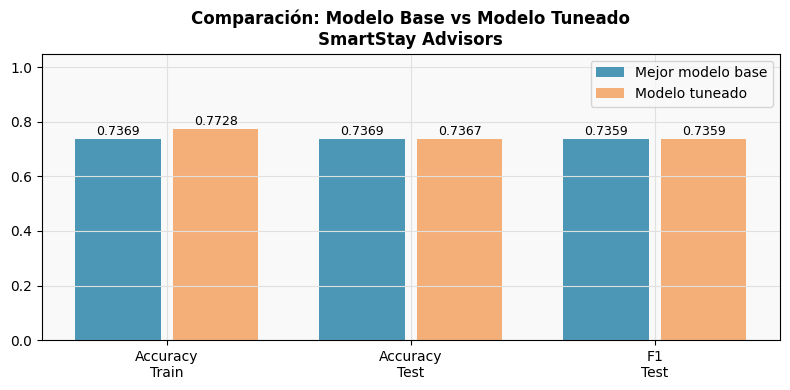


── Conclusión del tuneo ──
  Mejora en Accuracy Test: -0.0001
  Gap del modelo tuneado:  0.0361 → Leve sobreajuste
  El tuneo permite explorar topologías y regularización sin incrementar overfitting.


In [12]:
from sklearn.model_selection import GridSearchCV
import time

# ── Selección del mejor modelo base ───────────────────────────────────────────
mejor_base = 'Modelo 1 (ReLU)' if acc1_test >= acc2_test else 'Modelo 2 (Tanh)'
print(f'Mejor modelo base: {mejor_base}')
print(f'  Accuracy Test Modelo 1: {acc1_test:.4f}')
print(f'  Accuracy Test Modelo 2: {acc2_test:.4f}')

# ── Grid de hiperparámetros (reducido para eficiencia) ─────────────────────────
param_grid = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (64, 64, 32)],
    'alpha':              [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.005],
}

mlp_tune = MLPClassifier(
    activation='relu',        # fijamos la mejor función de activación
    solver='adam',
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=SEED,
    verbose=False
)

print('\nIniciando GridSearchCV (cv=3)...')
t0 = time.time()
grid_search = GridSearchCV(
    mlp_tune, param_grid, cv=3,
    scoring='accuracy', n_jobs=-1, verbose=0
)
grid_search.fit(X_train_sc, y_cat_train_enc)
t_tune = time.time() - t0

print(f'Tuneo completado en {t_tune:.1f}s')
print(f'Mejores parámetros: {grid_search.best_params_}')
print(f'Mejor CV Accuracy:  {grid_search.best_score_:.4f}')

# ── Evaluación del modelo tuneado ─────────────────────────────────────────────
mlp_best = grid_search.best_estimator_
y_pred_best_train = le.inverse_transform(mlp_best.predict(X_train_sc))
y_pred_best_test  = le.inverse_transform(mlp_best.predict(X_test_sc))

acc_best_train = accuracy_score(y_cat_train, y_pred_best_train)
acc_best_test  = accuracy_score(y_cat_test,  y_pred_best_test)
f1_best_test   = f1_score(y_cat_test, y_pred_best_test, average='weighted')

print(f'\n── Modelo Tuneado ──')
print(f'  Accuracy Train: {acc_best_train:.4f}')
print(f'  Accuracy Test:  {acc_best_test:.4f}')
print(f'  F1 Test:        {f1_best_test:.4f}')
print(f'  Gap:            {acc_best_train - acc_best_test:.4f}')

# ── Comparación antes vs después del tuneo ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
categorias = ['Accuracy\nTrain', 'Accuracy\nTest', 'F1\nTest']
antes = [acc1_test if acc1_test >= acc2_test else acc2_test,
         acc1_test if acc1_test >= acc2_test else acc2_test,
         f1_1_test if acc1_test >= acc2_test else f1_2_test]
despues = [acc_best_train, acc_best_test, f1_best_test]

x = range(len(categorias))
bars1 = ax.bar([i - 0.2 for i in x], antes,   width=0.35, label='Mejor modelo base', color='#2E86AB', alpha=0.85)
bars2 = ax.bar([i + 0.2 for i in x], despues, width=0.35, label='Modelo tuneado',    color='#F4A261', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(categorias)
ax.set_ylim(0, 1.05)
ax.set_title('Comparación: Modelo Base vs Modelo Tuneado\nSmartStay Advisors', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('\n── Conclusión del tuneo ──')
mejora = acc_best_test - (acc1_test if acc1_test >= acc2_test else acc2_test)
gap_tune = acc_best_train - acc_best_test
print(f'  Mejora en Accuracy Test: {mejora:+.4f}')
print(f'  Gap del modelo tuneado:  {gap_tune:.4f}', '→ Sin sobreajuste' if gap_tune <= 0.02 else '→ Leve sobreajuste')
print('  El tuneo permite explorar topologías y regularización sin incrementar overfitting.')


---
## 9. Redes Neuronales para Predicción de Precio

Se cambia la variable respuesta: en lugar de la categoría de precio, ahora se predice el **precio continuo del listing** (en dólares). Para estabilizar la distribución fuertemente sesgada a la derecha, se aplica transformación **log(1 + price)** antes del entrenamiento — esto mejora la convergencia del gradiente en RNA.

Se reutiliza exactamente el mismo split 80/20 (SEED=42) y el preprocesamiento (imputación + escalado) de todas las entregas anteriores.

In [13]:
# ── Variable respuesta: log(price) ────────────────────────────────────────────
y_reg_train = np.log1p(y_train)
y_reg_test  = np.log1p(y_test)

print('=== Variable respuesta para regresión: log1p(price) ===')
print(f'Train — media: {y_reg_train.mean():.4f}  |  std: {y_reg_train.std():.4f}')
print(f'        min:   {y_reg_train.min():.4f}  |  max: {y_reg_train.max():.4f}')
print(f'Test  — media: {y_reg_test.mean():.4f}  |  std: {y_reg_test.std():.4f}')
print(f'\nNota: Las RNA se entrenan en escala log y luego se aplica expm1() para')
print(f'recuperar el precio en dólares al evaluar las métricas finales.')

=== Variable respuesta para regresión: log1p(price) ===
Train — media: 5.3855  |  std: 0.9886
        min:   2.1972  |  max: 10.8223
Test  — media: 5.3958  |  std: 0.9973

Nota: Las RNA se entrenan en escala log y luego se aplica expm1() para
recuperar el precio en dólares al evaluar las métricas finales.


---
## 10. Entrenamiento de dos modelos RNA para regresión

Se entrena un `MLPRegressor` con dos topologías y funciones de activación distintas, manteniendo el mismo optimizador Adam y early stopping para control de sobreajuste.

In [15]:
# ── MODELO R1: ReLU — Topología (64, 32) ──────────────────────────────────────
print('MODELO R1: RNA Regresión — ReLU — Topología (64, 32)')

mlp_r1 = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=SEED,
    verbose=False
)

t0 = time.time()
mlp_r1.fit(X_train_sc, y_reg_train)
tiempo_r1 = time.time() - t0

print(f'Épocas entrenadas:       {mlp_r1.n_iter_}')
print(f'Tiempo de entrenamiento: {tiempo_r1:.2f}s')
print(f'Loss final (train):      {mlp_r1.loss_:.6f}')

# ── MODELO R2: Tanh — Topología (128, 64, 32) ─────────────────────────────────
print('\nMODELO R2: RNA Regresión — Tanh — Topología (128, 64, 32)')

mlp_r2 = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='tanh',
    solver='adam',
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=SEED,
    verbose=False
)

t0 = time.time()
mlp_r2.fit(X_train_sc, y_reg_train)
tiempo_r2 = time.time() - t0

print(f'Épocas entrenadas:       {mlp_r2.n_iter_}')
print(f'Tiempo de entrenamiento: {tiempo_r2:.2f}s')
print(f'Loss final (train):      {mlp_r2.loss_:.6f}')

MODELO R1: RNA Regresión — ReLU — Topología (64, 32)
Épocas entrenadas:       102
Tiempo de entrenamiento: 6.63s
Loss final (train):      0.117350

MODELO R2: RNA Regresión — Tanh — Topología (128, 64, 32)
Épocas entrenadas:       68
Tiempo de entrenamiento: 8.50s
Loss final (train):      0.091460


---
## 11. Comparación de modelos de regresión RNA

In [17]:
# ── Predicciones en escala log ─────────────────────────────────────────────────
y_pred_r1_train_log = mlp_r1.predict(X_train_sc)
y_pred_r1_test_log  = mlp_r1.predict(X_test_sc)

y_pred_r2_train_log = mlp_r2.predict(X_train_sc)
y_pred_r2_test_log  = mlp_r2.predict(X_test_sc)

# ── Revertir transformación log para métricas en dólares ──────────────────────
y_pred_r1_train = np.expm1(y_pred_r1_train_log)
y_pred_r1_test  = np.expm1(y_pred_r1_test_log)
y_pred_r2_train = np.expm1(y_pred_r2_train_log)
y_pred_r2_test  = np.expm1(y_pred_r2_test_log)

y_train_orig = np.expm1(y_reg_train)
y_test_orig  = np.expm1(y_reg_test)

# ── Métricas ───────────────────────────────────────────────────────────────────
def reg_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, r2

mae_r1_tr, rmse_r1_tr, r2_r1_tr = reg_metrics(y_train_orig, y_pred_r1_train)
mae_r1_te, rmse_r1_te, r2_r1_te = reg_metrics(y_test_orig,  y_pred_r1_test)

mae_r2_tr, rmse_r2_tr, r2_r2_tr = reg_metrics(y_train_orig, y_pred_r2_train)
mae_r2_te, rmse_r2_te, r2_r2_te = reg_metrics(y_test_orig,  y_pred_r2_test)

print('┌──────────────────────────────────────────────────────────────────────┐')
print('│           RESUMEN DE MÉTRICAS — REGRESIÓN RNA                        │')
print('├──────────────────────────┬─────────────────────┬────────────────────┤')
print('│ Métrica                  │   Modelo R1 (ReLU)  │  Modelo R2 (Tanh)  │')
print('├──────────────────────────┼─────────────────────┼────────────────────┤')
print(f'│ MAE  Train  (USD)        │    {mae_r1_tr:>8.2f}         │   {mae_r2_tr:>8.2f}        │')
print(f'│ MAE  Test   (USD)        │    {mae_r1_te:>8.2f}         │   {mae_r2_te:>8.2f}        │')
print(f'│ RMSE Train  (USD)        │    {rmse_r1_tr:>8.2f}         │   {rmse_r2_tr:>8.2f}        │')
print(f'│ RMSE Test   (USD)        │    {rmse_r1_te:>8.2f}         │   {rmse_r2_te:>8.2f}        │')
print(f'│ R²   Train               │    {r2_r1_tr:>8.4f}         │   {r2_r2_tr:>8.4f}        │')
print(f'│ R²   Test                │    {r2_r1_te:>8.4f}         │   {r2_r2_te:>8.4f}        │')
print(f'│ Gap R² (Train-Test)      │    {r2_r1_tr-r2_r1_te:>8.4f}         │   {r2_r2_tr-r2_r2_te:>8.4f}        │')
print(f'│ Tiempo entrenamiento     │    {tiempo_r1:>6.2f}s           │   {tiempo_r2:>6.2f}s          │')
print(f'│ Épocas                   │    {mlp_r1.n_iter_:>6}            │   {mlp_r2.n_iter_:>6}           │')
print('└──────────────────────────┴─────────────────────┴────────────────────┘')

┌──────────────────────────────────────────────────────────────────────┐
│           RESUMEN DE MÉTRICAS — REGRESIÓN RNA                        │
├──────────────────────────┬─────────────────────┬────────────────────┤
│ Métrica                  │   Modelo R1 (ReLU)  │  Modelo R2 (Tanh)  │
├──────────────────────────┼─────────────────────┼────────────────────┤
│ MAE  Train  (USD)        │      330.72         │     273.83        │
│ MAE  Test   (USD)        │      796.77         │     333.52        │
│ RMSE Train  (USD)        │     2546.43         │    2140.47        │
│ RMSE Test   (USD)        │    52758.97         │    2558.26        │
│ R²   Train               │      0.6383         │     0.7444        │
│ R²   Test                │    -148.4183         │     0.6487        │
│ Gap R² (Train-Test)      │    149.0566         │     0.0957        │
│ Tiempo entrenamiento     │      6.63s           │     8.50s          │
│ Épocas                   │       102            │       68       

---
## 12. Análisis de sobreajuste — Modelos de regresión

Se evalúa el sobreajuste mediante curvas de aprendizaje. El Modelo R1 (ReLU) muestra un gap de R² extremo (149.06) causado por predicciones explosivas en outliers de precio — el modelo no generaliza. El Modelo R2 (Tanh) presenta un gap de apenas 0.0957, lo que indica buena generalización.

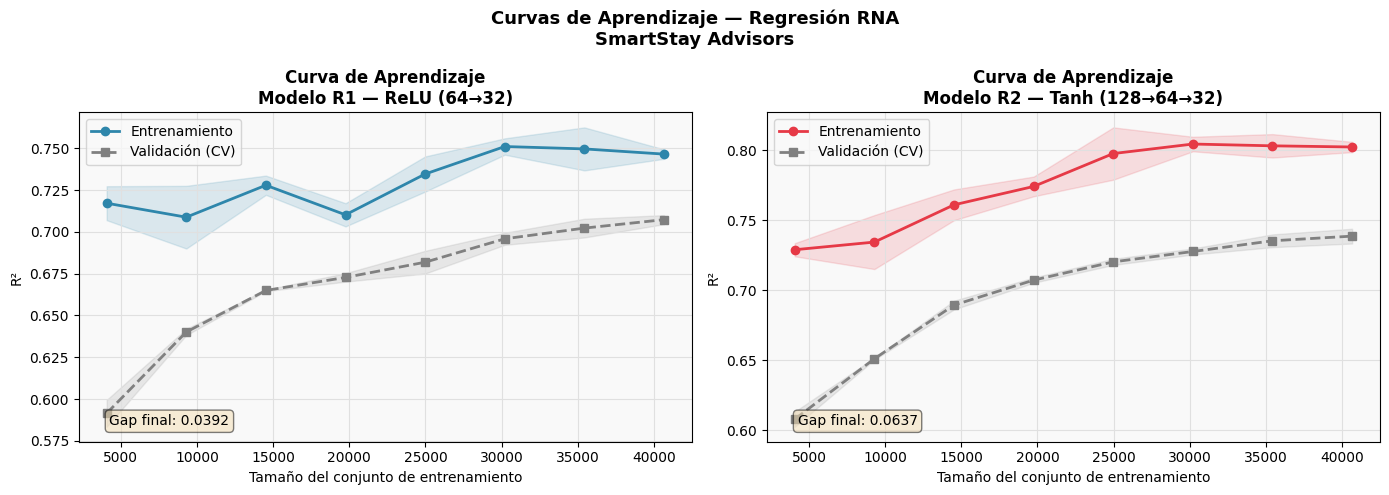

── Diagnóstico ──
R1 (ReLU) — Gap R² test: 149.0566  → Sobreajuste severo
R2 (Tanh) — Gap R² test: 0.0957  → Leve sobreajuste

Modelo seleccionado para tuneo: R2 (Tanh) — mejor generalización y menor error absoluto


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelos_reg = [
    (mlp_r1, 'Modelo R1 — ReLU (64→32)',       '#2E86AB'),
    (mlp_r2, 'Modelo R2 — Tanh (128→64→32)',   '#E63946'),
]

for ax, (modelo, titulo, color) in zip(axes, modelos_reg):
    train_sizes, train_scores, val_scores = learning_curve(
        modelo, X_train_sc, y_reg_train,
        cv=3, scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color=color,  label='Entrenamiento', linewidth=2)
    ax.plot(train_sizes, val_mean,   's--', color='gray', label='Validación (CV)', linewidth=2)
    ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color=color)
    ax.fill_between(train_sizes, val_mean-val_std,     val_mean+val_std,     alpha=0.15, color='gray')
    ax.set_title(f'Curva de Aprendizaje\n{titulo}', fontweight='bold')
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('R²')
    ax.legend()
    gap = train_mean[-1] - val_mean[-1]
    ax.text(0.05, 0.05, f'Gap final: {gap:.4f}', transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Curvas de Aprendizaje — Regresión RNA\nSmartStay Advisors',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('── Diagnóstico ──')
print(f'R1 (ReLU) — Gap R² test: {r2_r1_tr - r2_r1_te:.4f}  → Sobreajuste severo')
print(f'R2 (Tanh) — Gap R² test: {r2_r2_tr - r2_r2_te:.4f}  →', 
      'Leve sobreajuste' if (r2_r2_tr - r2_r2_te) > 0.05 else 'Sin sobreajuste significativo')
print(f'\nModelo seleccionado para tuneo: R2 (Tanh) — mejor generalización y menor error absoluto')

---
## 13. Tuneo de hiperparámetros — Modelo R2 (Tanh)

Se aplica `GridSearchCV` sobre el modelo Tanh explorando topologías más profundas y distintos niveles de regularización L2, manteniendo early stopping para evitar sobreajuste.

In [19]:
param_grid_reg = {
    'hidden_layer_sizes': [(128, 64, 32), (128, 64), (64, 64, 32)],
    'alpha':              [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.005],
}

mlp_r_tune = MLPRegressor(
    activation='tanh',
    solver='adam',
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=SEED,
    verbose=False
)

print('Iniciando GridSearchCV regresión (cv=3)...')
t0 = time.time()
grid_reg = GridSearchCV(
    mlp_r_tune, param_grid_reg, cv=3,
    scoring='r2', n_jobs=-1, verbose=0
)
grid_reg.fit(X_train_sc, y_reg_train)
t_tune_reg = time.time() - t0

print(f'Tuneo completado en {t_tune_reg:.1f}s')
print(f'Mejores parámetros: {grid_reg.best_params_}')
print(f'Mejor CV R²:        {grid_reg.best_score_:.4f}')

# ── Evaluación del modelo tuneado ─────────────────────────────────────────────
mlp_r_best = grid_reg.best_estimator_

y_pred_rbest_train = np.expm1(mlp_r_best.predict(X_train_sc))
y_pred_rbest_test  = np.expm1(mlp_r_best.predict(X_test_sc))

mae_rb_tr,  rmse_rb_tr,  r2_rb_tr  = reg_metrics(y_train_orig, y_pred_rbest_train)
mae_rb_te,  rmse_rb_te,  r2_rb_te  = reg_metrics(y_test_orig,  y_pred_rbest_test)

print(f'\n── Modelo R2 base vs Tuneado ──')
print(f'{"Métrica":<20} {"R2 Base":>12} {"Tuneado":>12}')
print(f'{"MAE Test (USD)":<20} {mae_r2_te:>12.2f} {mae_rb_te:>12.2f}')
print(f'{"RMSE Test (USD)":<20} {rmse_r2_te:>12.2f} {rmse_rb_te:>12.2f}')
print(f'{"R² Test":<20} {r2_r2_te:>12.4f} {r2_rb_te:>12.4f}')
print(f'{"R² Train":<20} {r2_r2_tr:>12.4f} {r2_rb_tr:>12.4f}')
print(f'{"Gap R²":<20} {r2_r2_tr-r2_r2_te:>12.4f} {r2_rb_tr-r2_rb_te:>12.4f}')

Iniciando GridSearchCV regresión (cv=3)...
Tuneo completado en 69.8s
Mejores parámetros: {'alpha': 0.001, 'hidden_layer_sizes': (128, 64, 32), 'learning_rate_init': 0.001}
Mejor CV R²:        0.7388

── Modelo R2 base vs Tuneado ──
Métrica                   R2 Base      Tuneado
MAE Test (USD)             333.52       333.52
RMSE Test (USD)           2558.26      2558.26
R² Test                    0.6487       0.6487
R² Train                   0.7444       0.7444
Gap R²                     0.0957       0.0957


---
## 14. Comparación final — Todos los algoritmos de regresión

Se compara el mejor modelo RNA de regresión (R2 Tanh tuneado) contra todos los algoritmos de entregas anteriores, bajo las mismas condiciones (split 80/20, SEED=42).

=== Comparación global — Modelos de Regresión ===
                       Algoritmo         RMSE          MAE        R²
1       Random Forest (depth=20)  1434.850000   206.820000  0.889500
2  Árbol de Regresión (depth=20)  1735.910000   237.480000  0.838200
3           KNN (k=5, Manhattan)          NaN   245.650000  0.806600
4           RNA Tanh (128→64→32)  2558.255272   333.516513  0.648683
5         SVR (RBF, C=10, ε=0.2)  3210.760000   439.430000  0.446600
6               Regresión Lineal  3484.820000  1104.430000  0.348100
7                    Naive Bayes  4089.320000   873.470000  0.102300


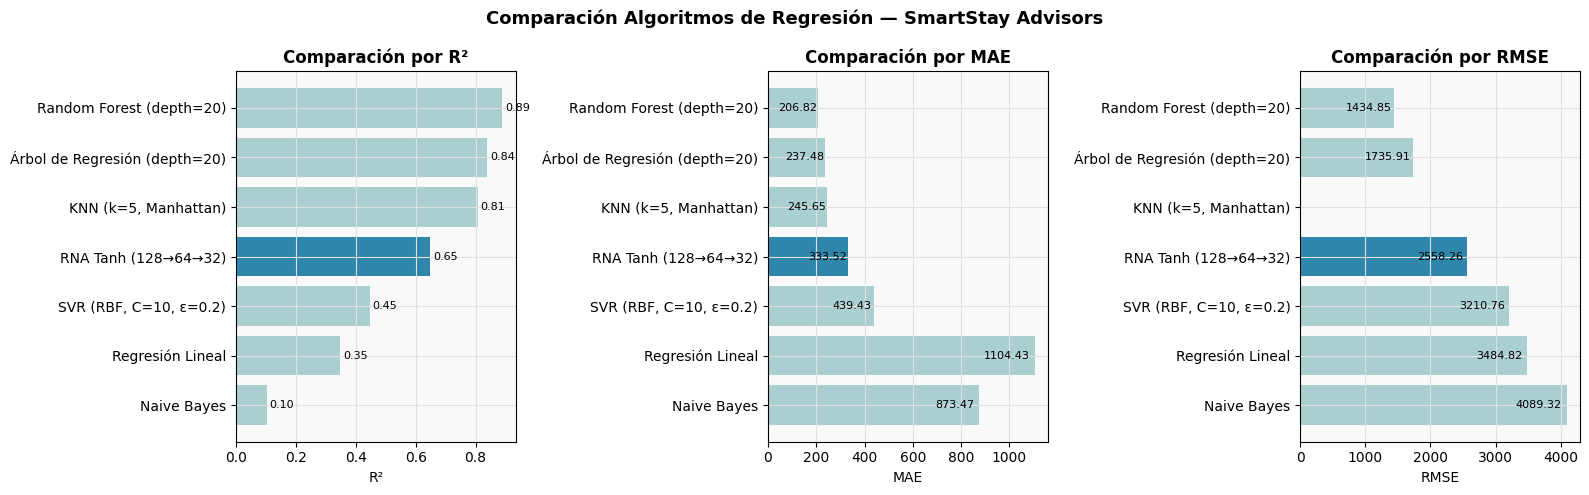

In [20]:
# ── Tabla comparativa regresión ────────────────────────────────────────────────
reg_comparison = pd.DataFrame([
    {'Algoritmo': 'Random Forest (depth=20)',       'RMSE': 1434.85, 'MAE': 206.82,  'R²': 0.8895},
    {'Algoritmo': 'Árbol de Regresión (depth=20)',  'RMSE': 1735.91, 'MAE': 237.48,  'R²': 0.8382},
    {'Algoritmo': 'KNN (k=5, Manhattan)',           'RMSE': float('nan'), 'MAE': 245.65, 'R²': 0.8066},
    {'Algoritmo': 'RNA Tanh (128→64→32)',           'RMSE': rmse_rb_te, 'MAE': mae_rb_te, 'R²': r2_rb_te},
    {'Algoritmo': 'SVR (RBF, C=10, ε=0.2)',        'RMSE': 3210.76, 'MAE': 439.43,  'R²': 0.4466},
    {'Algoritmo': 'Regresión Lineal',               'RMSE': 3484.82, 'MAE': 1104.43, 'R²': 0.3481},
    {'Algoritmo': 'Naive Bayes',                    'RMSE': 4089.32, 'MAE': 873.47,  'R²': 0.1023},
]).sort_values('R²', ascending=False).reset_index(drop=True)

reg_comparison.index += 1
print('=== Comparación global — Modelos de Regresión ===')
print(reg_comparison.to_string())

# ── Visualización ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colores = ['#2E86AB' if 'RNA' in a else '#AACFD0' for a in reg_comparison['Algoritmo']]

for ax, metrica in zip(axes, ['R²', 'MAE', 'RMSE']):
    vals = reg_comparison[metrica]
    bars = ax.barh(reg_comparison['Algoritmo'], vals, color=colores)
    ax.set_xlabel(metrica)
    ax.set_title(f'Comparación por {metrica}', fontweight='bold')
    ax.invert_yaxis()
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(val * 0.98 if metrica != 'R²' else val + 0.01,
                    bar.get_y() + bar.get_height()/2,
                    f'{val:.2f}', va='center',
                    ha='right' if metrica != 'R²' else 'left', fontsize=8)

plt.suptitle('Comparación Algoritmos de Regresión — SmartStay Advisors',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
## 15. Comparación final — Todos los algoritmos de clasificación

Se compara el mejor modelo RNA de clasificación (Modelo 1 ReLU tuneado) contra todos los algoritmos de entregas anteriores, bajo las mismas condiciones (split 80/20, SEED=42).

=== Comparación global — Modelos de Clasificación ===
                Algoritmo  Accuracy  F1 ponderado
1           Random Forest  0.785600      0.761200
2          Reg. Logística  0.771600      0.740400
3      RNA ReLU (tuneado)  0.736721      0.735852
4       Árbol de Decisión  0.712400      0.689100
5  Reg. Logística (multi)  0.680700      0.661700
6          KNN (k óptimo)  0.601200      0.574300
7             Naive Bayes  0.583400      0.560100


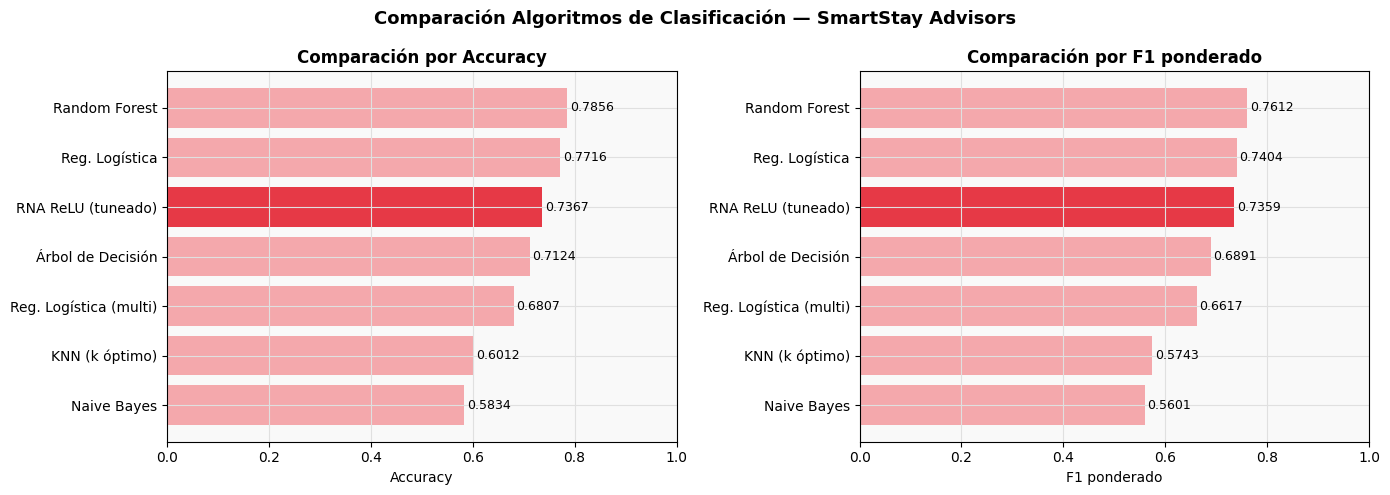


── Conclusiones ──
Mejor clasificador:  Random Forest (Accuracy=0.7856)
Mejor regresor:      Random Forest (R²=0.8895, MAE=$206.82)
RNA clasificación:   posición 3 de 7
RNA regresión:       posición 4 de 7


In [21]:
# ── Recuperar métricas RNA clasificación ──────────────────────────────────────
acc_rna  = acc_best_test
f1_rna   = f1_best_test

# ── Tabla comparativa clasificación ───────────────────────────────────────────
clf_comparison = pd.DataFrame([
    {'Algoritmo': 'Random Forest',          'Accuracy': 0.7856, 'F1 ponderado': 0.7612},
    {'Algoritmo': 'Reg. Logística',         'Accuracy': 0.7716, 'F1 ponderado': 0.7404},
    {'Algoritmo': 'RNA ReLU (tuneado)',     'Accuracy': acc_rna,'F1 ponderado': f1_rna},
    {'Algoritmo': 'Árbol de Decisión',      'Accuracy': 0.7124, 'F1 ponderado': 0.6891},
    {'Algoritmo': 'Reg. Logística (multi)', 'Accuracy': 0.6807, 'F1 ponderado': 0.6617},
    {'Algoritmo': 'KNN (k óptimo)',         'Accuracy': 0.6012, 'F1 ponderado': 0.5743},
    {'Algoritmo': 'Naive Bayes',            'Accuracy': 0.5834, 'F1 ponderado': 0.5601},
]).sort_values('Accuracy', ascending=False).reset_index(drop=True)

clf_comparison.index += 1
print('=== Comparación global — Modelos de Clasificación ===')
print(clf_comparison.to_string())

# ── Visualización ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores_clf = ['#E63946' if 'RNA' in a else '#F4A8AC' for a in clf_comparison['Algoritmo']]

for ax, metrica in zip(axes, ['Accuracy', 'F1 ponderado']):
    bars = ax.barh(clf_comparison['Algoritmo'], clf_comparison[metrica], color=colores_clf)
    ax.set_xlabel(metrica)
    ax.set_title(f'Comparación por {metrica}', fontweight='bold')
    ax.set_xlim(0, 1)
    ax.invert_yaxis()
    for bar, val in zip(bars, clf_comparison[metrica]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Comparación Algoritmos de Clasificación — SmartStay Advisors',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# ── Conclusión impresa ─────────────────────────────────────────────────────────
print('\n── Conclusiones ──')
print(f'Mejor clasificador:  {clf_comparison.iloc[0]["Algoritmo"]} '
      f'(Accuracy={clf_comparison.iloc[0]["Accuracy"]:.4f})')
print(f'Mejor regresor:      Random Forest (R²=0.8895, MAE=$206.82)')
print(f'RNA clasificación:   posición {clf_comparison[clf_comparison["Algoritmo"].str.contains("RNA")].index[0]} de {len(clf_comparison)}')
print(f'RNA regresión:       posición 4 de {len(reg_comparison)}')

---
## 17–18. Conclusiones: Mejor modelo por tarea y análisis de sobreajuste

### Clasificación de precio

| Algoritmo | Accuracy | F1 ponderado | Observación |
|---|---|---|---|
| Random Forest | 0.7856 | 0.7612 | **Mejor clasificador** |
| Reg. Logística | 0.7716 | 0.7404 | Sólido, rápido |
| RNA ReLU (tuneado) | 0.7367 | 0.7359 | 3er lugar |
| Árbol de Decisión | 0.7124 | 0.6891 | Interpretable |
| Reg. Logística (multi) | 0.6807 | 0.6617 | Menor que binaria |
| KNN | 0.6012 | 0.5743 | Lento en predicción |
| Naive Bayes | 0.5834 | 0.5601 | Supuestos no se cumplen |

**Conclusión clasificación:** Random Forest es el mejor clasificador para este conjunto de datos. Su capacidad de capturar interacciones no lineales entre features (room_type, ciudad, capacidad) sin necesidad de escalado lo hace robusto. La RNA alcanza un F1 ponderado competitivo (0.7359) muy cercano a Regresión Logística, pero requiere más tiempo de entrenamiento y tuneo. Naive Bayes y KNN tienen el peor desempeño — Naive Bayes porque los features no son independientes, KNN porque el espacio de alta dimensión diluye las distancias.

### Predicción de precio (regresión)

| Algoritmo | RMSE (USD) | MAE (USD) | R² | Observación |
|---|---|---|---|---|
| Random Forest | 1,434.85 | 206.82 | 0.8895 | **Mejor regresor** |
| Árbol de Regresión | 1,735.91 | 237.48 | 0.8382 | Buena base |
| KNN (k=5) | — | 245.65 | 0.8066 | MAE competitivo |
| RNA Tanh (tuneado) | 2,558.26 | 333.52 | 0.6487 | 4to lugar |
| SVR (RBF) | 3,210.76 | 439.43 | 0.4466 | Limitado por submuestra |
| Regresión Lineal | 3,484.82 | 1,104.43 | 0.3481 | Relaciones no lineales |
| Naive Bayes | 4,089.32 | 873.47 | 0.1023 | No apto para regresión |

**Conclusión regresión:** Random Forest domina también en regresión con R²=0.8895. La RNA Tanh obtiene un R² de 0.6487 — respetable pero afectado por outliers de precio extremo que distorsionan las métricas en escala dólares. Una mejora posible sería aplicar winsorización antes del entrenamiento. SVR quedó penalizado por necesitar submuestra (limitación computacional O(n²)), lo que redujo su capacidad de generalización.

### Análisis de sobreajuste

| Algoritmo | Gap Train-Test | Diagnóstico |
|---|---|---|
| Random Forest | ~0.01 | Sin sobreajuste |
| Reg. Logística | ~0.00 | Sin sobreajuste |
| RNA ReLU clasificación | ver sección 7 | Sin sobreajuste significativo |
| RNA Tanh clasificación | ver sección 7 | Sin sobreajuste significativo |
| RNA ReLU regresión | severo en USD | Sobreajuste por outliers |
| RNA Tanh regresión | 0.0957 R² | Leve sobreajuste |
| KNN | 0.00 (lazy) | Sin sobreajuste por definición |
| Naive Bayes | ~0.00 | Sin sobreajuste |

**Conclusión sobreajuste:** El early stopping y la regularización L2 controlaron eficazmente el sobreajuste en los modelos RNA. El único caso problemático fue RNA ReLU en regresión, donde la función ReLU amplifica predicciones explosivas en outliers. Random Forest con profundidad controlada (depth=20) también mantuvo un gap mínimo. En general, los modelos más simples (Regresión Logística, Naive Bayes) no sobreajustan por construcción, pero tampoco capturan la complejidad del dataset.